In [11]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier

In [12]:
df = pd.read_csv("../datasets/ai4i2020.csv")

print(df.shape)

(10000, 14)


In [13]:
X = df.drop(
    columns=[
        "UDI",
        "Product ID",
        "Machine failure",
        "TWF",
        "HDF",
        "PWF",
        "OSF",
        "RNF",
    ]
)

y = df["Machine failure"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

Target:
Machine failure


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

In [15]:
categorical_features = [
    "Type"
]

numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),
        (
            "num",
            SimpleImputer(strategy="median"),
            numerical_features,
        ),
    ]
)

In [16]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Negative samples:", negative)
print("Positive samples:", positive)
print("Scale pos weight:", scale_pos_weight)

Negative samples: 7729
Positive samples: 271
Scale pos weight: 28.52029520295203


In [17]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=500,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,
                random_state=42,
                eval_metric="logloss",
            ),
        ),
    ]
)

In [18]:
pipeline.fit(X_train, y_train)

print("XGBoost training complete.")

XGBoost training complete.


In [19]:
feature_names = pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

print(feature_names)

['cat__Type_H' 'cat__Type_L' 'cat__Type_M' 'num__Air temperature [K]'
 'num__Process temperature [K]' 'num__Rotational speed [rpm]'
 'num__Torque [Nm]' 'num__Tool wear [min]']


In [20]:
importances = pipeline.named_steps[
    "classifier"
].feature_importances_

importance_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance": importances,
    }
)

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False,
)

importance_df

,Feature,Importance
6,num__Torque [Nm],0.272905
5,num__Rotational speed [rpm],0.210572
7,num__Tool wear [min],0.172866
3,num__Air temperature [K],0.095276
1,cat__Type_L,0.075332
4,num__Process temperature [K],0.066202
2,cat__Type_M,0.062730
0,cat__Type_H,0.044116


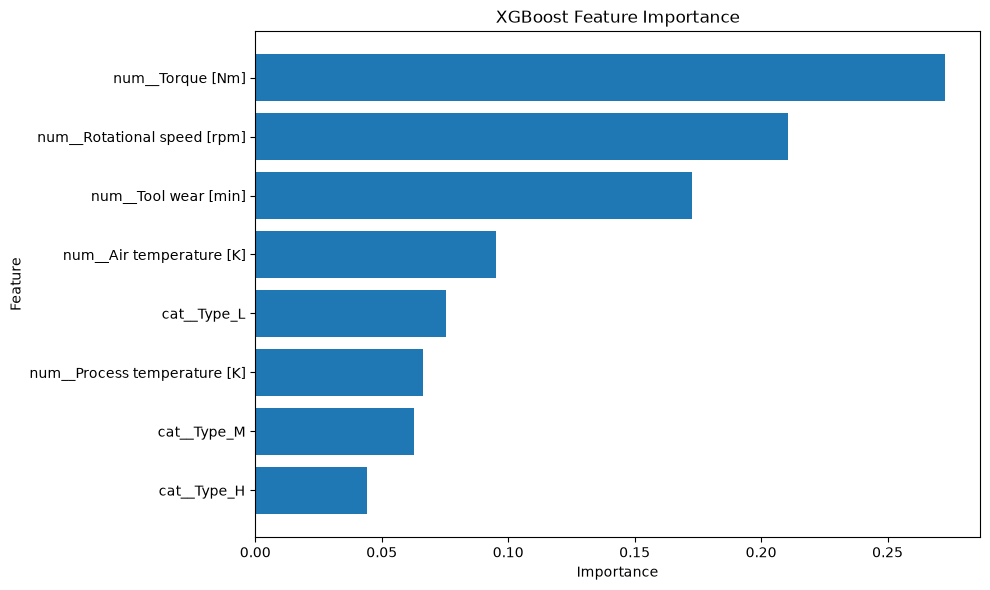

In [21]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"],
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()